# Log-Likelihood vs Pulsar Distance with a Single Continuous Gravitational Wave

This notebook generates **N** random pulsars, each with only:
- A **spindown** model (F0, F1)
- An **astrometry** component (sky position + parallax distance)
- **Simple unscaled white noise** (EFAC = 1, no EQUAD)

There is **no solar system Shapiro delay**.

A single **continuous gravitational wave (CGW)** signal is injected, and we sweep
the log-likelihood as a function of the first pulsar's distance (PX parameter).

**Convention:** `PX` is parallax in mas (PINT / `types.py`). `CWInjector`
converts internally to distance via `L_kpc = 1 / PX_mas` for the Ellis+2012
pulsar-term phase. The sweep iterates in mas; the plot displays on a kpc axis.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt 

In [2]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_1d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 42


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and distance.
The par file includes only spindown (F0, F1), astrometry (RAJ, DECJ, PX), and
unscaled white noise (EFAC = 1). No DM, no EQUAD.

In [3]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            1.359724
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [4]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD,
    end_mjd=END_MJD,
    n_toas=N_TOAS,
    toa_error_s=TOA_ERROR,
    freq_mhz=FREQ,
)
timing_models = list(synthetic.timing_models)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_mas = float(pp_tuple[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    f0 = float(pp_tuple[i].param_value("F0"))
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  "
        f"PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)  F0={f0:.1f} Hz"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")
print(f"Timing model for pulsar 0:\n{timing_models[0]}")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_

  Pulsar 0:        J1834-0701_00  PX=1.360 mas (d=0.74 kpc)  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX=0.615 mas (d=1.63 kpc)  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX=0.622 mas (d=1.61 kpc)  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX=0.481 mas (d=2.08 kpc)  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX=0.409 mas (d=2.45 kpc)  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX=0.453 mas (d=2.21 kpc)  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX=0.597 mas (d=1.67 kpc)  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX=0.460 mas (d=2.17 kpc)  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX=0.387 mas (d=2.58 kpc)  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX=1.177 mas (d=0.85 kpc)  F0=215.3 Hz

All 10 pulsars loaded.
Timing model for pulsar 0:
TimingModel(
  delay_components=(
    AstrometryEquatorial(px_name='PX'), SolarSystemShapiroDelay()
  ),
  phase_components=(Spindown(spin_param_names=('F0', 'F1')),)
)


## Set up a single CW source and inject into TOAs

We place one continuous gravitational wave source at a random sky location with
a nHz-band GW frequency and strain amplitude $h = 10^{-9}$ — deliberately
loud so the pulsar-term oscillation with distance is clearly visible.

In [5]:
cw_injectors, _ = build_cw_injectors(
    pint_models, n_sources=1, rng=rng, log10_h=-9.0,
)
cw_inj = cw_injectors[0]
print(
    f"CW source: cos_gwtheta={cw_inj.param_spec['cos_gwtheta']:.3f}, "
    f"gwphi={cw_inj.param_spec['gwphi']:.3f}, "
    f"log10_fgw={cw_inj.param_spec['log10_fgw']:.2f}"
)

gp, config_sig = inject_and_build_config(synthetic, cw_injectors)
print("PTA config built with 1 CW source.")


CW source: cos_gwtheta=-0.600, gwphi=0.046, log10_fgw=-7.43
PTA config built with 1 CW source.


## Sweep log-likelihood vs distance for pulsar 0

We vary the distance (PX parameter) of pulsar 0 over a fine grid while holding
all other parameters fixed. The CW pulsar-term phase depends on distance as
$\phi_p = \phi_e - 2\pi f_{\rm gw} \frac{d}{c}(1 + \cos\mu)$,
so the likelihood oscillates with distance.

In [6]:
TARGET_PULSAR = 0
true_px_mas = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
true_distance = 1.0 / true_px_mas  # kpc
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc "
      f"(PX = {true_px_mas:.4f} mas)")

half_window = 0.01  # kpc (x-axis window in distance)
distance_grid = np.linspace(
    true_distance - half_window,
    true_distance + half_window,
    1000,
)
px_mas_grid = 1.0 / distance_grid

def eval_logL_at_distance(px_mas_value, _gp=gp, _cfg=config_sig):
    mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_value)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(_gp, pp_mod, _cfg)

logL_values_sig = sweep_1d_logL(eval_logL_at_distance, px_mas_grid)
print(f"Sweep complete ({len(px_mas_grid)} points)")

Pulsar 0 true distance: 0.735 kpc (PX = 1.3597 mas)
Sweep complete (1000 points)


## Plot

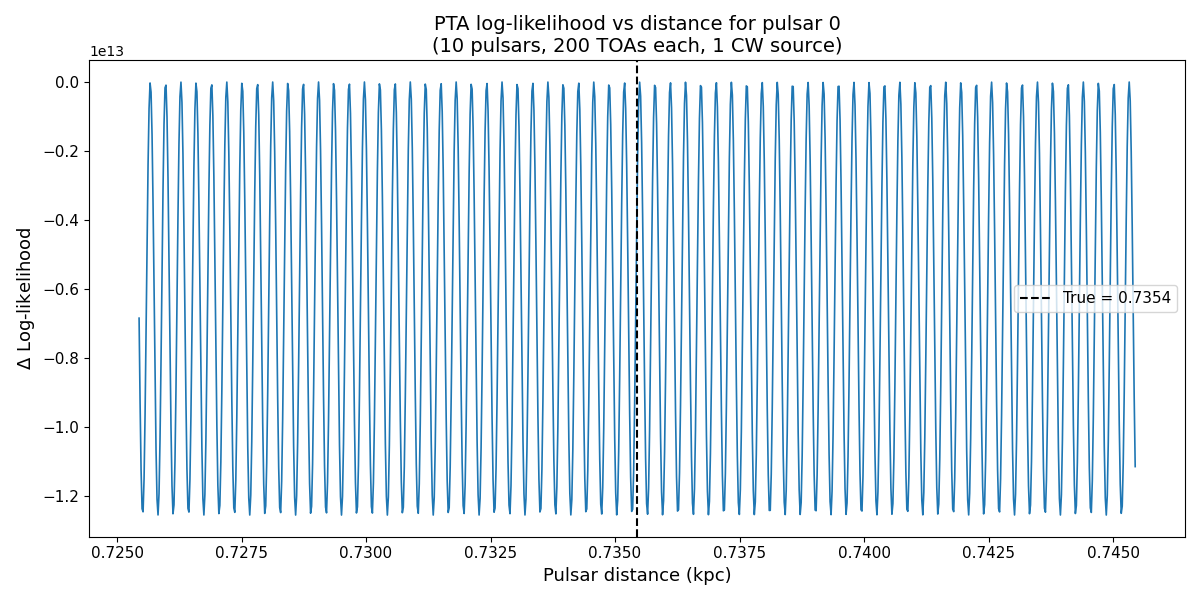

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_1d_delta_logL(
    ax, distance_grid, logL_values_sig,
    true_value=true_distance, xlabel="Pulsar distance (kpc)",
)
ax.set_title(
    f"PTA log-likelihood vs distance for pulsar {TARGET_PULSAR}\n"
    f"({N_PULSARS} pulsars, {N_TOAS} TOAs each, 1 CW source)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()